# Improved Weather Forecasting Pipeline

Improvements over the original notebook:
- **Cyclical time encoding** — hour, day-of-year, month encoded as sin/cos pairs instead of raw integers
- **Wind direction as sin/cos** — circular encoding for both features and target, avoiding the 359°↔1° discontinuity
- **Two-stage precipitation model** — XGBClassifier (rain/no-rain) + log-transformed XGBRegressor (amount), eliminating zero-inflation bias
- **Per-target XGBoost with early stopping** — replaces MultiOutputRegressor, uses val set to stop overfitting
- **Richer features** — difference/change features, longer lags (48h, 168h), rolling min/max, plus `dew_point_2m`, `surface_pressure`, and `weather_code` now used as inputs
- **Wind direction MAE reported in degrees** — reconstructs angle from sin/cos predictions for interpretable evaluation

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor, XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

In [10]:
FORECAST_HORIZON = 24   # predict 6 timesteps ahead

BASE_TARGET_COLS = [
    "temperature_2m",
    "weather_code",
    "apparent_temperature",
    "precipitation",
    "relative_humidity_2m",
]

In [11]:
df = pd.read_csv('/home/makos/dev/weather_dag/raw_data/city_data_2026-05-22_17-12-01.csv', index_col=0)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f"Loaded {len(df):,} rows | columns: {list(df.columns)}")
df.head()

Loaded 17,544 rows | columns: ['date', 'temperature_2m', 'weather_code', 'apparent_temperature', 'precipitation', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m']


,date,temperature_2m,weather_code,apparent_temperature,precipitation,relative_humidity_2m,dew_point_2m,surface_pressure,wind_speed_10m,wind_direction_10m
0,2024-04-14 00:00:00+00:00,11.7595,3.0,10.717299,0.0,78.057710,8.0595,910.40910,3.671294,101.309900
1,2024-04-14 01:00:00+00:00,12.2095,3.0,10.925562,0.0,75.521110,8.0095,910.28894,5.241679,105.945465
2,2024-04-14 02:00:00+00:00,12.0595,3.0,10.888635,0.0,76.011246,7.9595,910.41900,4.379589,99.462250
3,2024-04-14 03:00:00+00:00,11.7095,3.0,10.643064,0.0,76.733795,7.7595,910.21250,3.319036,49.398785
4,2024-04-14 04:00:00+00:00,10.1595,3.0,8.813246,0.0,82.200250,7.2595,909.69336,4.394360,34.992100


In [12]:
def engineer_features(df: pd.DataFrame, target_cols: list, horizon: int = 1) -> pd.DataFrame:
    df = df.copy().sort_values('date').reset_index(drop=True)
    
    hour       = df['date'].dt.hour
    doy        = df['date'].dt.dayofyear
    month      = df['date'].dt.month
    dow        = df['date'].dt.dayofweek

    df['hour_sin']   = np.sin(2 * np.pi * hour / 24)
    df['hour_cos']   = np.cos(2 * np.pi * hour / 24)
    df['doy_sin']    = np.sin(2 * np.pi * doy / 365)
    df['doy_cos']    = np.cos(2 * np.pi * doy / 365)
    df['month_sin']  = np.sin(2 * np.pi * month / 12)
    df['month_cos']  = np.cos(2 * np.pi * month / 12)
    df['dow_sin']    = np.sin(2 * np.pi * dow / 7)
    df['dow_cos']    = np.cos(2 * np.pi * dow / 7)

    for col in target_cols:
        if col not in df.columns:
            continue

        for lag in [1, 3, 6, 12, 24, 48, 168]:
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)
            
        for window in [6, 12, 24]:
            s = df[col].shift(1)
            df[f'{col}_roll_mean_{window}']  = s.rolling(window).mean()
            df[f'{col}_roll_std_{window}']   = s.rolling(window).std()
            df[f'{col}_roll_max_{window}']   = s.rolling(window).max()
            df[f'{col}_roll_min_{window}']   = s.rolling(window).min()

        df[f'{col}_diff_1']  = df[col].diff(1).shift(1)   # 1-step change
        df[f'{col}_diff_6']  = df[col].diff(6).shift(1)   # 6-step change
        df[f'{col}_diff_24'] = df[col].diff(24).shift(1)  # 24-step change

    for col in target_cols:
        if col not in df.columns:
            continue
        else:
            df[f'target_{col}'] = df[col].shift(-horizon)

    df = df.dropna().reset_index(drop=True)
    return df

In [13]:
df_processed = engineer_features(df, BASE_TARGET_COLS, FORECAST_HORIZON)

TARGET_COLS = []
for c in BASE_TARGET_COLS:
    TARGET_COLS.append(f'target_{c}')

print(f"Processed shape: {df_processed.shape}")
print(f"Targets: {TARGET_COLS}")
df_processed.head(3)

Processed shape: (17352, 133)
Targets: ['target_temperature_2m', 'target_weather_code', 'target_apparent_temperature', 'target_precipitation', 'target_relative_humidity_2m']


,date,temperature_2m,weather_code,apparent_temperature,precipitation,relative_humidity_2m,dew_point_2m,surface_pressure,wind_speed_10m,wind_direction_10m,...,relative_humidity_2m_roll_max_24,relative_humidity_2m_roll_min_24,relative_humidity_2m_diff_1,relative_humidity_2m_diff_6,relative_humidity_2m_diff_24,target_temperature_2m,target_weather_code,target_apparent_temperature,target_precipitation,target_relative_humidity_2m
0,2024-04-21 00:00:00+00:00,14.5095,0.0,13.289251,0.0,66.798940,8.4095,912.30817,5.506941,168.69011,...,78.14062,47.708588,-2.705688,21.559978,-4.146278,13.8595,0.0,12.680294,0.0,69.906320
1,2024-04-21 01:00:00+00:00,12.9595,0.0,11.530752,0.0,75.136765,8.6595,912.51820,7.386582,226.97493,...,78.14062,47.708588,-2.883166,19.090352,0.617765,13.8595,0.0,12.861479,0.0,69.906320
2,2024-04-21 02:00:00+00:00,13.0095,0.0,11.520732,0.0,75.910470,8.8595,913.07510,8.161764,221.42357,...,78.14062,47.708588,8.337825,24.371312,11.195265,14.3095,0.0,13.157915,0.0,65.187584


In [14]:
def build_datasets(df: pd.DataFrame, target_cols: list, base_target_cols: list):
    cols_to_exclude = set(target_cols) | set(base_target_cols) | {'date'}
    feature_cols = [c for c in df.columns if c not in cols_to_exclude]

    n = len(df)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train_df = df.iloc[:train_end]
    val_df   = df.iloc[train_end:val_end]
    test_df  = df.iloc[val_end:]

    return (
        train_df[feature_cols], train_df[target_cols],
        val_df[feature_cols],   val_df[target_cols],
        test_df[feature_cols],  test_df[target_cols],
        feature_cols
    )


X_train, y_train, X_val, y_val, X_test, y_test, feature_cols = build_datasets(
    df_processed, TARGET_COLS, BASE_TARGET_COLS
)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Features used: {len(feature_cols)}")

Train: (12146, 122)  Val: (2603, 122)  Test: (2603, 122)
Features used: 122


In [15]:
def train_models(X_train, y_train, X_val, y_val, target_cols):
    
    xgb_params = dict(
        n_estimators      = 1000,  # early stopping will cut this down
        max_depth         = 6,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        objective         = 'reg:squarederror',
        random_state      = 42,
        device            = 'cpu',
    )

    models = {}
    weather_clf = None

    for col in target_cols:
        print(f"  Training {col} ...", end=' ')

        if col == 'weather_code':
            weather_clf = XGBClassifier(
                n_estimators     = 1000,
                max_depth        = 5,
                learning_rate    = 0.05,
                subsample        = 0.8,
                colsample_bytree = 0.8,
                random_state     = 42,
                device           = 'cpu',
                early_stopping_rounds = 30,
                eval_metric      = 'logloss',
            )
            weather_clf.fit(
                X_train, y_train[col],
                eval_set=[(X_val, y_val[col])],
                verbose=False
            )

        else:
            reg = XGBRegressor(**xgb_params, early_stopping_rounds=30)
            reg.fit(
                X_train, y_train[col],
                eval_set=[(X_val, y_val[col])],
                verbose=False
            )
            models[col] = reg
            print(f"best_iter={reg.best_iteration}")

    return models, weather_clf


print("Training per-target models with early stopping ...")
models, rain_clf = train_models(X_train, y_train, X_val, y_val, TARGET_COLS)

Training per-target models with early stopping ...
  Training target_temperature_2m ... best_iter=83
  Training target_weather_code ... best_iter=13
  Training target_apparent_temperature ... best_iter=107
  Training target_precipitation ... best_iter=6
  Training target_relative_humidity_2m ... best_iter=88


In [16]:
def predict(models, weather_clf, X, target_cols):

    preds = {}
    for col in target_cols:
        if col == 'weather_code' :
            weather_code = weather_clf.predict(X)
            preds[col] = weather_code 
        else:
            preds[col] = models[col].predict(X)
    return pd.DataFrame(preds, index=X.index)

Evaluating on test set ...


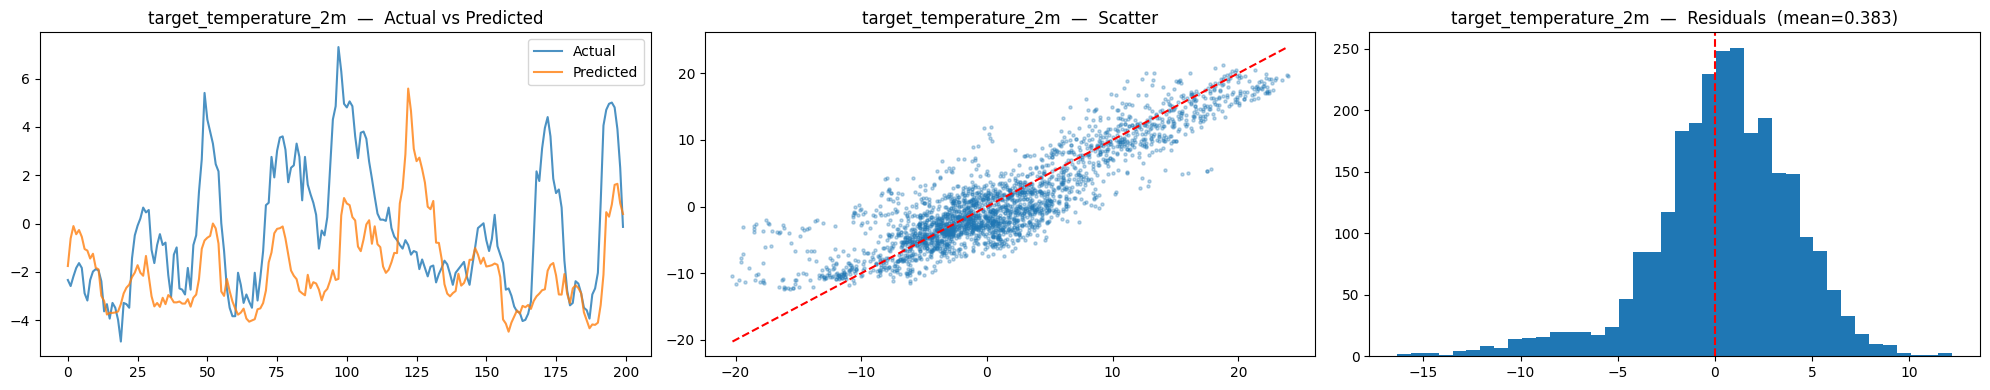

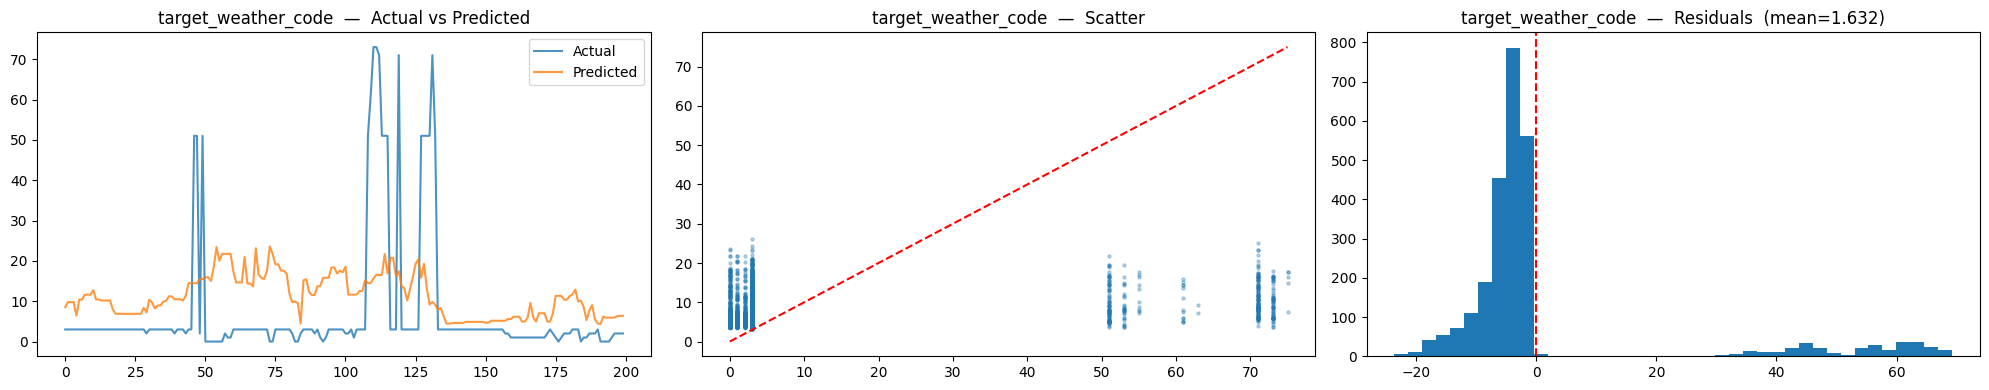

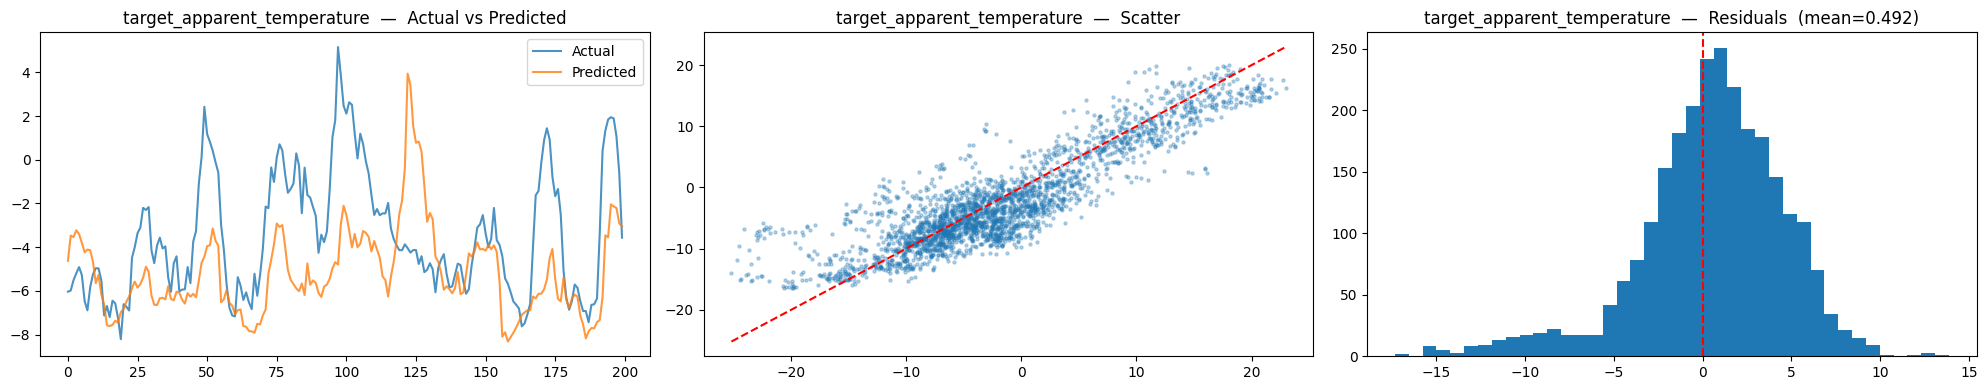

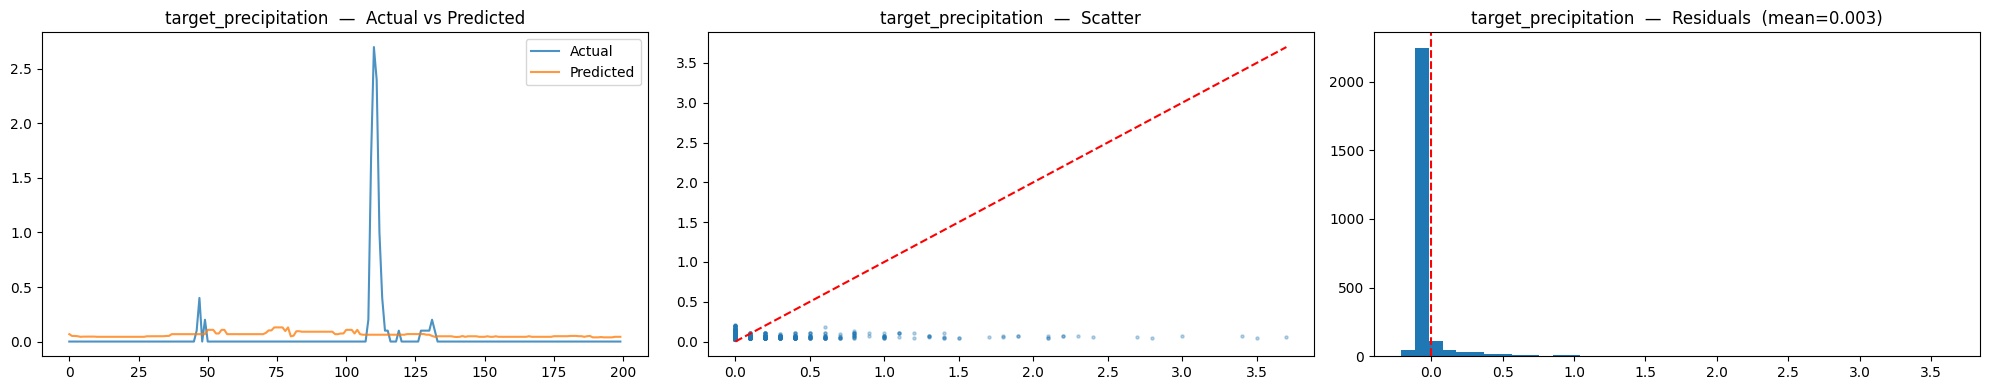

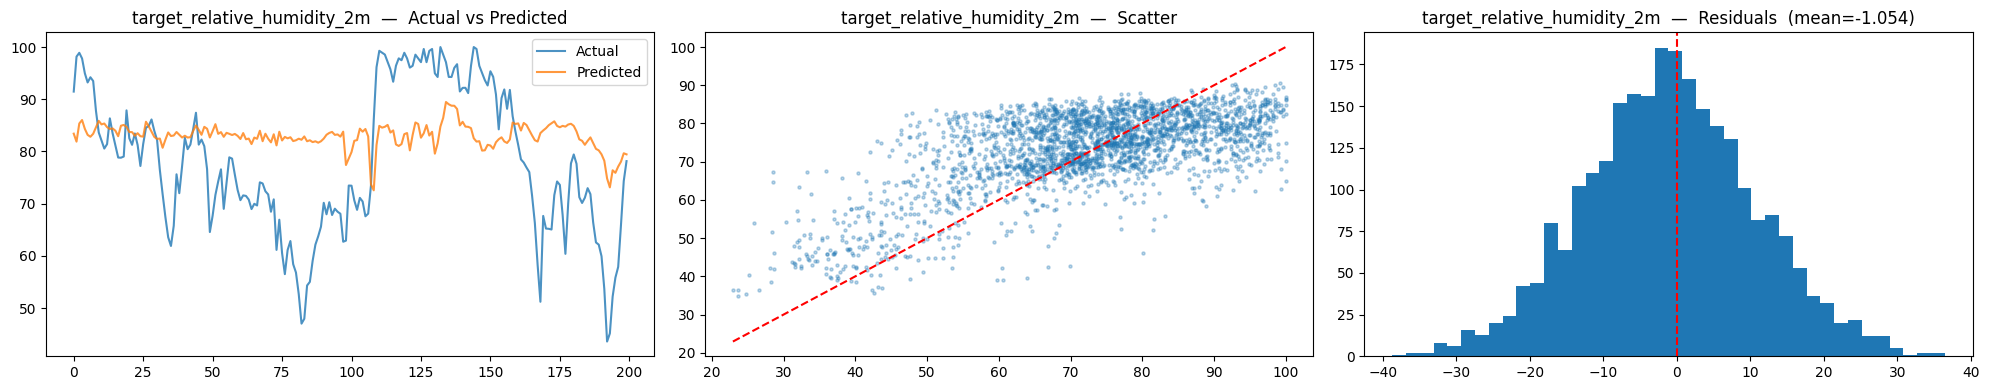

,MAE,RMSE,R2
target_temperature_2m,2.819828,3.750519,0.785555
target_weather_code,11.175715,19.820553,0.059854
target_apparent_temperature,3.128563,4.147965,0.782558
target_precipitation,0.097429,0.257038,0.008784
target_relative_humidity_2m,9.255571,11.660532,0.406793


In [17]:
def circular_mae_degrees(y_true_sin, y_true_cos, y_pred_sin, y_pred_cos):
    """Mean absolute error in degrees for a circular target."""
    true_angles = np.rad2deg(np.arctan2(y_true_sin, y_true_cos)) % 360
    pred_angles = np.rad2deg(np.arctan2(y_pred_sin, y_pred_cos)) % 360
    diff = np.abs(true_angles - pred_angles)
    diff = np.minimum(diff, 360 - diff)   # wrap-around distance
    return diff.mean()


def evaluate_model(models, rain_clf, X_test, y_test, target_cols, n_plot=200):
    preds_df = predict(models, rain_clf, X_test, target_cols)
    metrics = {}

    for col in target_cols:
        y_true = y_test[col].values
        y_pred = preds_df[col].values

        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)
        metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

        fig, axes = plt.subplots(1, 3, figsize=(20, 4))
        axes[0].plot(y_true[:n_plot], label='Actual',    alpha=0.8)
        axes[0].plot(y_pred[:n_plot], label='Predicted', alpha=0.8)
        axes[0].set_title(f'{col}  —  Actual vs Predicted')
        axes[0].legend()

        axes[1].scatter(y_true, y_pred, alpha=0.3, s=5)
        lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        axes[1].plot([lo, hi], [lo, hi], 'r--')
        axes[1].set_title(f'{col}  —  Scatter')

        residuals = y_true - y_pred
        axes[2].hist(residuals, bins=40)
        axes[2].axvline(0, color='r', linestyle='--')
        axes[2].set_title(f'{col}  —  Residuals  (mean={residuals.mean():.3f})')

        plt.tight_layout()
        plt.show()

    return pd.DataFrame(metrics).T


print("Evaluating on test set ...")
metrics_df = evaluate_model(models, rain_clf, X_test, y_test, TARGET_COLS)
metrics_df

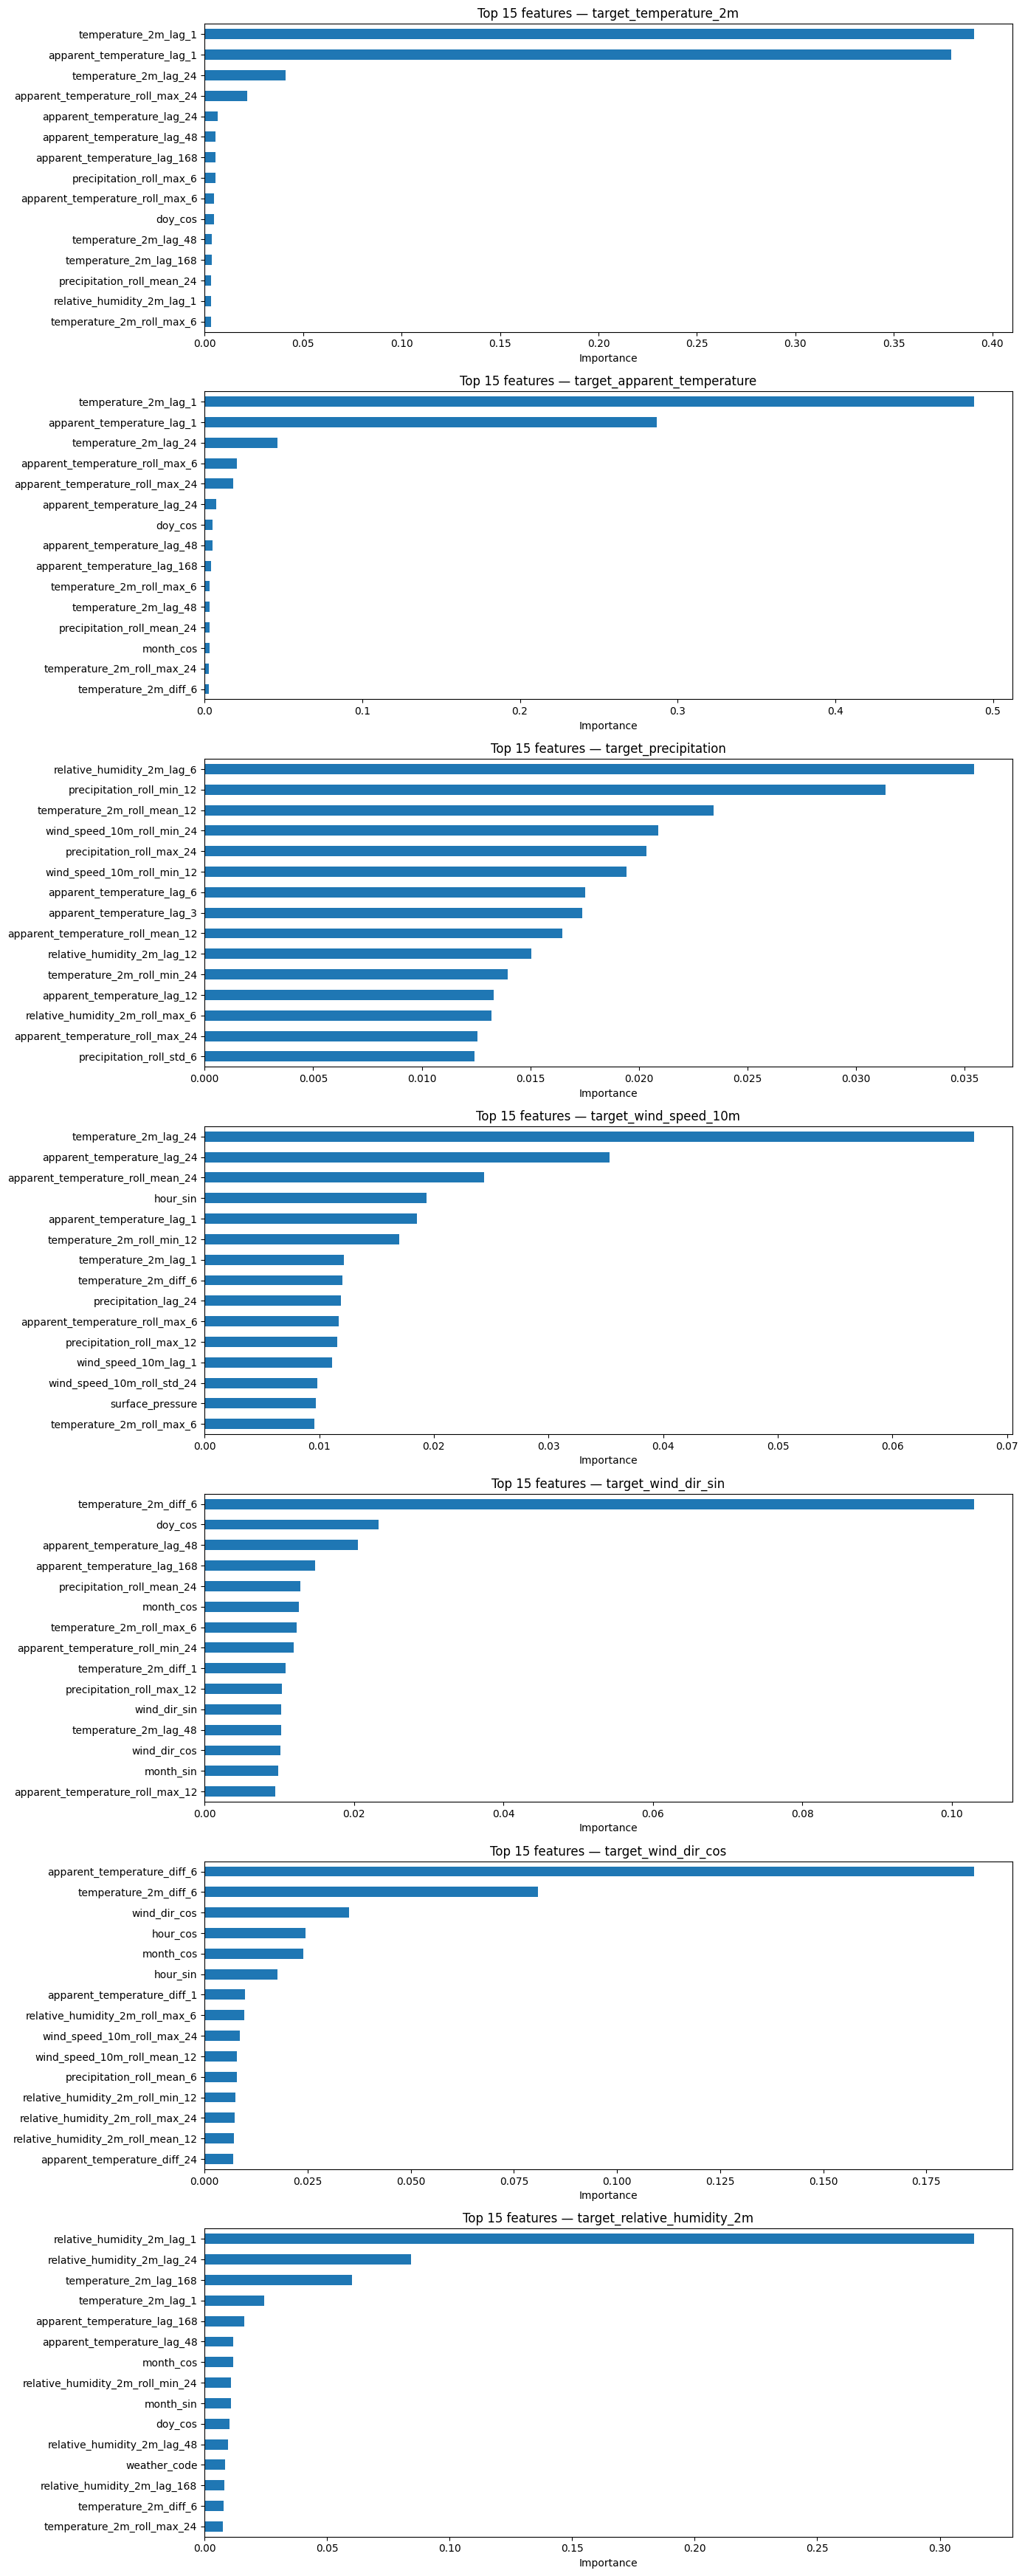

In [21]:
# ── Feature importances for each model ────────────────────────────────────────
n_top = 15

fig, axes = plt.subplots(len(TARGET_COLS), 1, figsize=(14, 5 * len(TARGET_COLS)))
for ax, col in zip(axes, TARGET_COLS):
    imp = pd.Series(models[col].feature_importances_, index=feature_cols)
    imp.nlargest(n_top).sort_values().plot.barh(ax=ax)
    ax.set_title(f'Top {n_top} features — {col}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [ ]:
# joblib.dump(
#     {'models': models, 'rain_clf': rain_clf, 'feature_cols': feature_cols},
#     'weather_forecaster_improved.pkl'
# )
# print("Saved → weather_forecaster_improved.pkl")

Saved → weather_forecaster_improved.pkl
